### Reflexion
- Agent's self-correction or self-improvement, allowing agent to,
    - Iteratively refine its output
    - Adjust its approach based
       - Feedback
       - Internal critique
       - Comparison against desired criteria
- Agent evaluating its own work, output or internal state
- Using this evaluation to improve its performance or refine its response.
- Reflection introduces a feedback loop.

In [52]:
import os
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from langchain_openai import ChatOpenAI

load_dotenv()

True

In [53]:
model = ChatOpenAI(model="gpt-4o-mini", temperature=0.5)

In [54]:
class AgentState(TypedDict):
    input: str
    draft: str
    feedback: str
    iteration: int
    max_iterations: int
    final_output: str

In [55]:
#Node 1: Generate summary
def generate_summary(input: AgentState):

    system_msg = f"""
    You are an expert in generating consise product summary for any idea or concept. 
    Write a concise summary for the following user input.
    """
    user_msg = f"""
    User idea or concept: {input['input']}
    """

    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": user_msg},
    ]

    response = model.invoke(messages)
    draft = response.content.strip()
    print("Draft Summary:", draft[:100])
    return {"draft": draft}

In [64]:
#Node 2: Critique draft summary
def critique_summary(input: AgentState):

    system_msg = f"""
    Critique the following product draft summary for clarity, conciseness, appeal and completeness. 
    Provide specific, actionable feedback to improve the draft.
    You can just say "draft_approved" if the draft is good enough and has decent quality.
    """
    user_msg = f"""
    Input idea or concept: {input['input']}
    Draft summary: {input['draft']}
    """

    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": user_msg},
    ]

    response = model.invoke(messages)
    critique = response.content.strip()
    print("Critique Summary:", critique[:100])
    return {
        "feedback": critique,
        "iteration": input["iteration"] + 1
    }

In [65]:
#Node 3: Refine summary
def refine_summary(input: AgentState):

    system_msg = f"""
    Refine the following product draft summary based on the critique feedback for given user input.
    """
    user_msg = f"""
    Input idea or concept: {input['input']}
    Draft summary: {input['draft']}
    Feedback: {input['feedback']}
    """

    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": user_msg},
    ]

    response = model.invoke(messages)
    refined_summary = response.content.strip()
    print("Refined Summary:", refined_summary[:100])
    return {
        "refined_summary": refined_summary
    }

In [66]:
#Node 4: Finalize summary
def finalize_summary(input: AgentState):

    return { "final_output": input["draft"] }

In [67]:
from typing import Literal


def check_termination(input: AgentState) -> Literal["refine", "finalize"]:
    print(f"Current Iteration:{input['iteration']} / {input['max_iterations']}")

    if "draft_approved" in input.get("feedback", "").lower():
        return "finalize"
        
    if input["iteration"] < input["max_iterations"]:
        return "refine"
    else:
        return "finalize"

In [68]:
workflow = StateGraph(AgentState)

workflow.add_node("generate", generate_summary)
workflow.add_node("refine", refine_summary)
workflow.add_node("critique", critique_summary)
workflow.add_node("finalize", finalize_summary)

workflow.set_entry_point("generate")
workflow.add_edge("generate", "critique")
workflow.add_conditional_edges(
    "critique",
    check_termination,
    {
        "refine": "refine",
        "finalize": "finalize"
    }
)
workflow.add_edge("refine", "critique")
workflow.add_edge("finalize", END)

graph = workflow.compile()

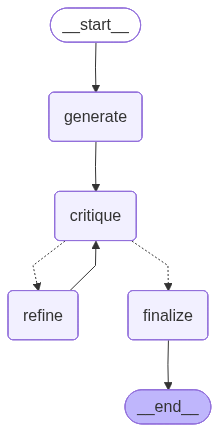

In [69]:
from IPython.display import display, Image
from langchain_core.runnables.graph import MermaidDrawMethod

graph_image = graph.get_graph().draw_mermaid_png(
    draw_method=MermaidDrawMethod.API
)

display(Image(graph_image))

In [70]:
input_idea = "A smart water bottle that tracks your hydration levels and reminds you to drink water throughout the day."

result = graph.invoke({
    "input": input_idea,
    "iteration": 0,
    "max_iterations": 10,
})


Draft Summary: Introducing the Smart Hydration Bottle: a cutting-edge water bottle that monitors your hydration lev
Critique Summary: The draft summary is a solid start but could benefit from some improvements in clarity, conciseness,
Current Iteration:1 / 10
Refined Summary: **Revised Draft Summary**:

Introducing the Smart Hydration Bottle: a revolutionary water bottle fea
Critique Summary: The draft summary is generally clear and conveys the main features of the product; however, there ar
Current Iteration:2 / 10
Refined Summary: Introducing the Smart Hydration Bottle: a sleek and innovative water bottle that tracks your hydrati
Critique Summary: 1. **Clarity**: The draft is mostly clear, but it could benefit from a brief explanation of how the 
Current Iteration:3 / 10
Refined Summary: **Revised Summary**: 

"Introducing the Smart Hydration Bottle: a sleek and innovative water bottle 
Critique Summary: The draft summary is a good start but could benefit from some improvements for c

In [71]:
print("Final Summary Output:\n", result["final_output"])

Final Summary Output:
 Introducing the Smart Hydration Bottle: a cutting-edge water bottle that monitors your hydration levels and sends timely reminders to keep you on track throughout the day. With its sleek design and integrated technology, it ensures you stay properly hydrated, promoting overall health and well-being. Perfect for fitness enthusiasts and busy individuals alike, this bottle makes hydration effortless and effective.
